# 욜로 테스트 

In [3]:
from ultralytics import YOLO
import cv2 
import glob
import os

# 1) 모델 로드
model = YOLO("best_strong3.pt")

# 2) 테스트 이미지 폴더
img_dir = "lr_real"
extensions = ["*.jpg", "*.jpeg", "*.png"]

# 3) 이미지 수집
img_paths = []
for ext in extensions:
    img_paths.extend(glob.glob(os.path.join(img_dir, ext)))

print(f"총 {len(img_paths)}장의 이미지 로드됨.")

# 결과 저장 폴더 생성
os.makedirs("results", exist_ok=True)

# 4) 이미지 반복 처리
for i, img_path in enumerate(img_paths):
    img = cv2.imread(img_path)

    if img is None:
        print(f"이미지 로드 실패: {img_path}")
        continue

    # YOLO 추론
    results = model(img)[0]

    # 박스 그리기
    for box in results.boxes:
        if box.conf >= 00:  # 신뢰도 임계값 설정
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls = int(box.cls)
            conf = float(box.conf)
            label = f"{model.names[cls]} {conf:.2f}"

            cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
            cv2.putText(img, label, (int(x1), int(y1)-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
        else:
            continue
    

    # 화면 출력
    cv2.imshow("result", img) 
    key = cv2.waitKey(0)
    cv2.destroyAllWindows()

    if key == 27:  # ESC
        break


총 184장의 이미지 로드됨.

0: 480x640 1 right, 116.0ms
Speed: 51.4ms preprocess, 116.0ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 210.2ms
Speed: 29.3ms preprocess, 210.2ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 371.1ms
Speed: 2.8ms preprocess, 371.1ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 137.9ms
Speed: 25.0ms preprocess, 137.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 134.8ms
Speed: 7.1ms preprocess, 134.8ms inference, 7.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 375.2ms
Speed: 3.9ms preprocess, 375.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 165.8ms
Speed: 4.8ms preprocess, 165.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 123.4ms
Speed: 2.3ms preprocess, 123.4ms inference, 1.3ms postprocess 

# z크롭 + 분류(좌,직,우 만)

In [ ]:
from ultralytics import YOLO
import cv2
import glob
import os
import numpy as np
import tensorflow as tf

# 1) YOLO + 보조 classifier 로드
model_yolo = YOLO("best_strong2.pt")
model_assist = tf.keras.models.load_model("assistance.keras")

# 보조 classifier의 클래스 이름 순서
assist_class_names = ["left", "right", "straight"]

IMG_SIZE = (224, 224)

# 2) 테스트 이미지 폴더
img_dir = "lr_real"
extensions = ["*.jpg", "*.jpeg", "*.png"]

img_paths = []
for ext in extensions:
    img_paths.extend(glob.glob(os.path.join(img_dir, ext)))

print(f"총 {len(img_paths)}장의 이미지 로드됨.")

os.makedirs("results", exist_ok=True)

# 3) YOLO + Assitance 모델 적용
for img_path in img_paths:

    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지 로드 실패: {img_path}")
        continue

    # YOLO 추론 (1차)
    results = model_yolo(img)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_yolo = int(box.cls)
        conf_yolo = float(box.conf)
        yolo_label = model_yolo.names[cls_yolo]

        # ---- 2차: 보조 classifier에 입력할 crop 준비 ----
        crop = img[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        crop_resized = cv2.resize(crop, IMG_SIZE)
        #crop_norm = crop_resized / 255.0
        crop_input = np.expand_dims(crop_resized, axis=0)

        # 보조 classifier 예측
        pred = model_assist.predict(crop_input, verbose=0)
        cls_assist = np.argmax(pred)
        assist_label = assist_class_names[cls_assist]
        conf_assist = float(np.max(pred))

        # ---- 3차 결정: 보조 classifier 결과로 보정 ----
        # 정책 예시:
        #  - 보조 모델 confidence가 더 높으면 보정
        #  - YOLO confidence가 낮을 때만 보정
        #  - 둘이 다르면 보조 모델 신뢰
        # 너 상황에서는 "보조 모델 우선"이 맞음.

        final_label = yolo_label

        # 보조 모델 신뢰도가 0.50 이상이고 YOLO와 다르면 → 보정
        if assist_label != yolo_label and conf_assist > 0.70:
            final_label = assist_label

        # ---- 결과 그리기 ----
        label_draw = f"{final_label} ({conf_yolo:.2f}/{conf_assist:.2f})"

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(img, label_draw, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    # 화면 표시
    cv2.imshow("result", img)
    key = cv2.waitKey(0)
    cv2.destroyAllWindows()

    if key == 27:  # ESC
        break


총 184장의 이미지 로드됨.

0: 480x640 1 right, 57.9ms
Speed: 25.0ms preprocess, 57.9ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 103.6ms
Speed: 3.1ms preprocess, 103.6ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 73.9ms
Speed: 28.3ms preprocess, 73.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 53.6ms
Speed: 2.2ms preprocess, 53.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 48.5ms
Speed: 1.2ms preprocess, 48.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 52.6ms
Speed: 5.1ms preprocess, 52.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 77.1ms
Speed: 39.5ms preprocess, 77.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 right, 94.8ms
Speed: 1.5ms preprocess, 94.8ms inference, 0.7ms postprocess per image at s

# EDA

▶ Analyzing folder: test
▶ Analyzing folder: real
▶ Analyzing folder: before


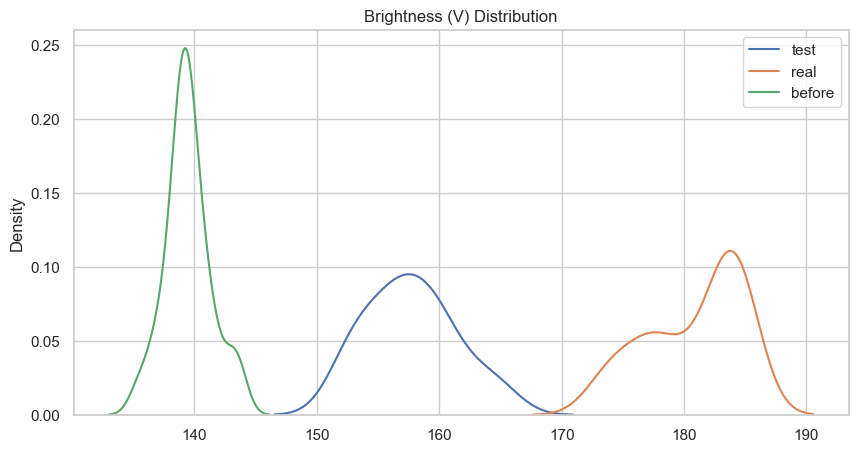

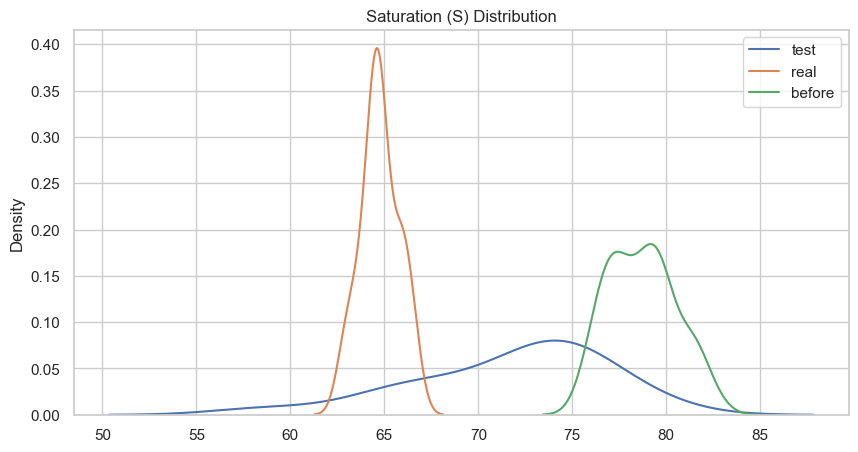

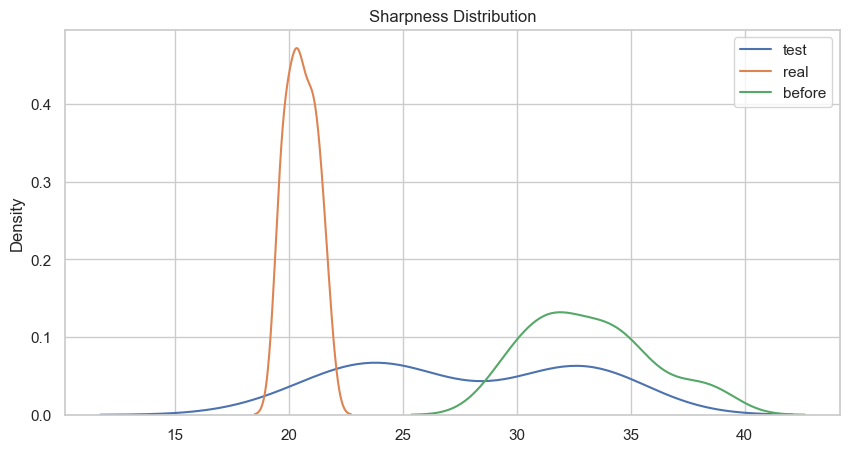

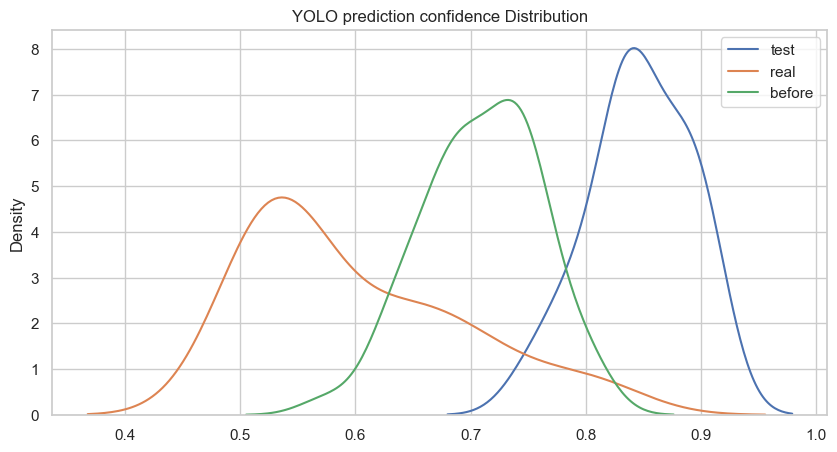

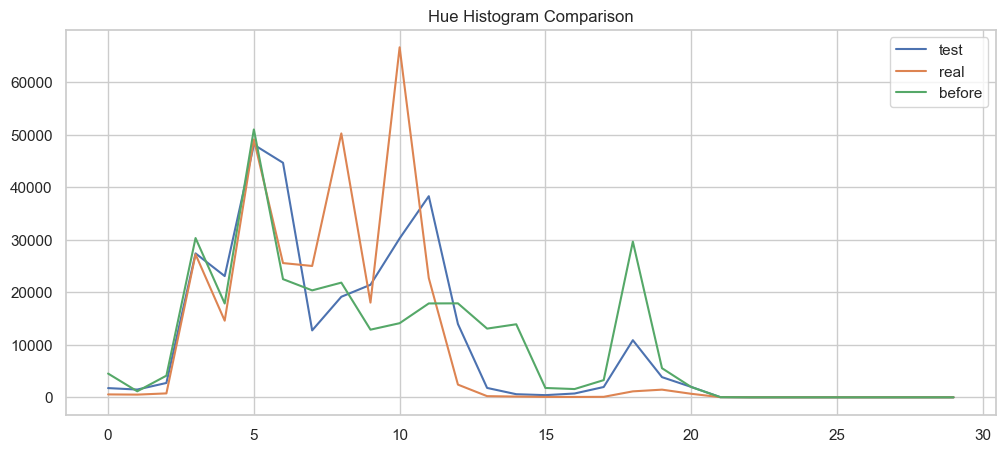

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
import seaborn as sns

model = YOLO("best.pt")

# -------------------------------------------------
# 📌 폴더 정의
# -------------------------------------------------
folders = {
    "test": "rights_test",
    "real": "rights_real",
    "before": "rights_before",
}

# -------------------------------------------------
# 📌 Helper 함수 (평균밝기, 색상, 채도, 선명도)
# -------------------------------------------------
def analyze_image(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    brightness = np.mean(v)
    saturation = np.mean(s)
    
    # Sharpness = Laplacian variance
    sharpness = cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var()

    return brightness, saturation, sharpness, h, s, v

# -------------------------------------------------
# 📌 폴더별 결과 저장
# -------------------------------------------------
results = {
    name: {
        "brightness": [],
        "saturation": [],
        "sharpness": [],
        "h_hist": [],
        "s_hist": [],
        "v_hist": [],
        "conf": []
    }
    for name in folders.keys()
}

# -------------------------------------------------
# 📌 폴더별 이미지 분석 실행
# -------------------------------------------------
for name, path in folders.items():
    print(f"▶ Analyzing folder: {name}")
    
    for fn in os.listdir(path):
        img_path = os.path.join(path, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # YOLO 예측
        pred = model(img, verbose=False)[0]
        if len(pred.boxes) > 0:
            conf = float(pred.boxes.conf[0])
        else:
            conf = 0.0

        # 분석
        brightness, saturation, sharpness, h, s, v = analyze_image(img)

        results[name]["brightness"].append(brightness)
        results[name]["saturation"].append(saturation)
        results[name]["sharpness"].append(sharpness)
        results[name]["conf"].append(conf)

        # 히스토그램 저장
        results[name]["h_hist"].append(np.histogram(h, bins=30, range=(0,255))[0])
        results[name]["s_hist"].append(np.histogram(s, bins=30, range=(0,255))[0])
        results[name]["v_hist"].append(np.histogram(v, bins=30, range=(0,255))[0])

# -------------------------------------------------
# 📌 시각화 — 각 지표 비교 그래프
# -------------------------------------------------
sns.set(style="whitegrid")

def plot_compare(metric, ylabel):
    plt.figure(figsize=(10,5))
    for name in folders.keys():
        sns.kdeplot(results[name][metric], label=name)
    plt.title(f"{ylabel} Distribution")
    plt.legend()
    plt.show()

plot_compare("brightness", "Brightness (V)")
plot_compare("saturation", "Saturation (S)")
plot_compare("sharpness", "Sharpness")

# Confidence 차이 확인
plot_compare("conf", "YOLO prediction confidence")

# -------------------------------------------------
# 📌 HSV 히스토그램 평균 비교
# -------------------------------------------------
plt.figure(figsize=(12,5))
for name in folders.keys():
    mean_h = np.mean(results[name]["h_hist"], axis=0)
    plt.plot(mean_h, label=name)
plt.title("Hue Histogram Comparison")
plt.legend()
plt.show()


In [47]:
import cv2
import numpy as np
import os
from ultralytics import YOLO

model = YOLO("best.pt")

folders = {
    "test": "rights_test",
    "real": "rights_real",
    "before": "rights_before",
}

def analyze_image(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    brightness = np.mean(v)
    saturation = np.mean(s)
    sharpness = cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.CV_64F).var()

    h_hist = np.histogram(h, bins=30, range=(0,255))[0]

    return brightness, saturation, sharpness, h_hist

summary = {}

for name, path in folders.items():
    brightness_list = []
    saturation_list = []
    sharpness_list = []
    h_hists = []
    conf_list = []

    for fn in os.listdir(path):
        img_path = os.path.join(path, fn)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # YOLO 예측
        pred = model(img, verbose=False)[0]
        if len(pred.boxes) > 0:
            conf = float(pred.boxes.conf[0])
        else:
            conf = 0.0
        conf_list.append(conf)

        # 분석
        b, s, sh, hh = analyze_image(img)
        brightness_list.append(b)
        saturation_list.append(s)
        sharpness_list.append(sh)
        h_hists.append(hh)

    summary[name] = {
        "brightness_mean": np.mean(brightness_list),
        "saturation_mean": np.mean(saturation_list),
        "sharpness_mean": np.mean(sharpness_list),
        "confidence_mean": np.mean(conf_list),
        "hue_hist_mean": np.mean(h_hists, axis=0).tolist()
    }

# 최종 출력
import json
print(json.dumps(summary, indent=4))


{
    "test": {
        "brightness_mean": 157.71921533203127,
        "saturation_mean": 71.72015771484374,
        "sharpness_mean": 27.71383577450276,
        "confidence_mean": 0.8464611887931823,
        "hue_hist_mean": [
            1752.2,
            1476.65,
            2731.4,
            27401.0,
            23081.4,
            48096.4,
            44656.3,
            12739.25,
            19141.85,
            21423.9,
            30255.1,
            38291.5,
            13956.7,
            1786.25,
            589.25,
            412.65,
            724.0,
            1960.05,
            10873.6,
            3839.2,
            1981.8,
            29.55,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            0.0
        ]
    },
    "real": {
        "brightness_mean": 180.82318780637257,
        "saturation_mean": 64.76716385186887,
        "sharpness_mean": 20.533278873281855,
        "conf

In [ ]:
def img_preprocess(image):
    height, _, _ = image.shape
    roi = image[int(height/2):, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    lower_yellow = np.array([15, 80, 80])
    upper_yellow = np.array([40, 255, 255])

    mask = cv2.inRange(hsv, lower_yellow, upper_yellow) 
    mask = cv2.GaussianBlur(mask, (5, 5), 0)
    mask = cv2.erode(mask, None, iterations=1)
    mask = cv2.dilate(mask, None, iterations=2)
    return mask

In [5]:
import cv2
import numpy as np
import glob
import os

# ----------------------------
# 기존 함수 그대로 사용
# ----------------------------
def img_preprocess(image):
    height, _, _ = image.shape
    roi = image
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    lower_yellow = np.array([15, 80, 80])
    upper_yellow = np.array([40, 255, 255])

    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask = cv2.GaussianBlur(mask, (5, 5), 0)
    mask = cv2.erode(mask, None, iterations=1)
    mask = cv2.dilate(mask, None, iterations=2)
    return mask

# ----------------------------
# 저장 스크립트
# ----------------------------
input_dir = "load"     # 라인 이미지 폴더
output_dir = "output_masks"    # 결과 저장 폴더
os.makedirs(output_dir, exist_ok=True)

image_paths = glob.glob(os.path.join(input_dir, "*.jpg")) \
               + glob.glob(os.path.join(input_dir, "*.png")) \
               + glob.glob(os.path.join(input_dir, "*.jpeg"))

print(f"총 {len(image_paths)}장 처리 시작")

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지 로드 실패: {img_path}")
        continue

    mask = img_preprocess(img)   # 노란색만 추출된 마스크

    # 파일명만 추출해서 저장
    filename = os.path.basename(img_path)
    save_path = os.path.join(output_dir, f"mask_{filename}")

    cv2.imwrite(save_path, mask)
    print(f"저장됨 → {save_path}")

print("처리 완료.")


총 9장 처리 시작
저장됨 → output_masks\mask_1761740125489.jpg
저장됨 → output_masks\mask_1761740125590.jpg
저장됨 → output_masks\mask_1761740125689.jpg
저장됨 → output_masks\mask_1761740125788.jpg
저장됨 → output_masks\mask_1761740125887.jpg
저장됨 → output_masks\mask_1761740125987.jpg
저장됨 → output_masks\mask_1761740126086.jpg
저장됨 → output_masks\mask_1761740126185.jpg
저장됨 → output_masks\mask_1761740126284.jpg
처리 완료.
